# **Multivariable Linear Regression Model**

<div align="center">
    <img src=".\img\multiple-regression.png" width="25%">
</div>

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [2]:
# CREATE DATASET
size = 120
k = 2   # feature number. EXPECTED: 5

x = np.array(np.random.rand(size, k+1)*100)
x[:,0] = 1
y = np.array([i + np.random.normal(0,0.9) for i in range(size)])*100

# display(x, y)
display(x.shape, y.shape)

(120, 3)

(120,)

In [3]:
# NORMALIZE DATA
r, c = x.shape
i = 0
for j in range(1,c):
    # Get max and min of current column
    max_x = np.amax(x[:,j])         
    min_x = np.amin(x[:,j])
    
    x[:,j] = np.array([(e - min_x)/(max_x - min_x) for e in x[:,j]])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

display(x.shape, y.shape)

(120, 3)

(120,)

Text(0.5, 0, 'y')

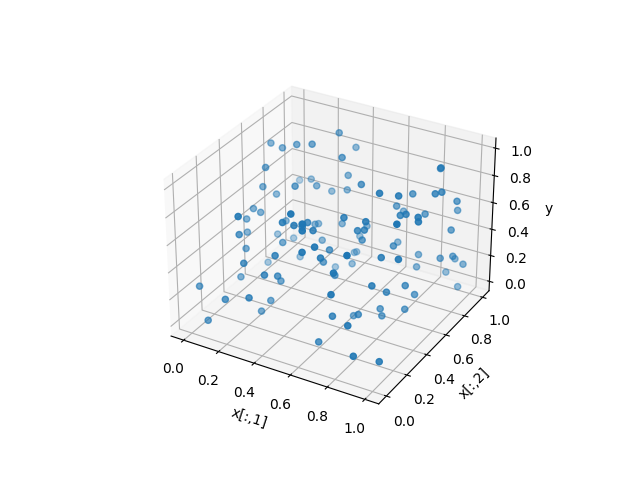

In [4]:
# 3D PLOT for 2 input 1 output
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x[:,1], x[:,2], y)
ax.set_xlabel('x[:,1]')
ax.set_ylabel('x[:,2]')
ax.set_zlabel('y')

## **Hypothesis**
For $n$ features:

$$h(x^{(i)}) = w_0*x^{(i)}_0 + w_1 * x^{(i)}_1 + w_2 * x^{(i)}_2 + w_n * x^{(i)}_n$$

Where:

$$x_0 = \text{implicit } 1$$

And exists $n + 1$ variables to predict. Then:

Viewing at it as arrays where each row of matrix $x$ is a training example and exists $j$ training examples, we have:

$$
x = 
\begin{bmatrix} 
1 & x_{1,1} & ... & x_{1,n} \\
1 & x_{2,1} & ... & x_{2,n} \\
1 & ... & ... & ... \\
1 & x_{j,1} & ... & x_{j,n}
\end{bmatrix}_{j*(n+1)}
$$ 

And $x^{(j)}_{n}$ represents "the j-th value of the n-th feature" or "the n-th feature of the j-th training example". In addition:

$$w = \begin{bmatrix} w_0 & w_1 & ... & w_n \end{bmatrix}_{1*(n+1)}$$

$$
y = \begin{bmatrix} y_1 & y_2 & ... & y_j \end{bmatrix}_{1*j}
$$

Thus:

$$h(x_j) = x_j * w^t$$

$$
h(x_j) = 
\begin{bmatrix} 1 & x_{j,1} & ... & x_{j,n}\end{bmatrix}_{1*(n+1)} *
\begin{bmatrix} w_0 \\ w_1 \\ ... \\ w_n \end{bmatrix}_{(n+1)*1} 
= \text{model prediction}
$$





In [5]:
def h(x, w):
  x = np.matrix(x)
  w = np.transpose(np.matrix(w))
  return np.dot(x, w)

## **Loss Function**

$$L(x) = \text{Error} = \frac{1}{2m}\sum_{i=0}^m (y_i - h(x_i)) ²$$


In [6]:
def Error(y, x, w):
  c, = y.shape
  e = 0
  for j in range(c):
    sum = float(y[j] - h(x[j,:], w))**2/(2.0*len(x))
    e = e + sum
  return e

## **Gradient Descent**

$$
\frac{\partial{L}}{\partial{w_0}} = \frac{1}{m}\sum_{i=0}^m(y_i - h(x^i))(-1) \\
\frac{\partial{L}}{\partial{w_{j\neq 0}}} = \frac{1}{m}\sum_{i=0}^m(y_i - h(x^i))(-x^{i}_{j})
$$

In [7]:
def derivada(x,y,params):
  #implementar las derivadas
  m, = y.shape
  r, c = x.shape

  # first derivative
  derivatives = np.array(
    [
      sum(
        [
          (y[i] - h(x[i,:],params))*-1 for i in range(m)
        ]
        )/(m*1.0)
    ]
  )
  
  for j in range(1, c):
    der = sum([(y[i] - h(x[i,:], params))*-x[i,j] for i in range(m)])/(m*1.0)
    derivatives = np.append(derivatives, der)
  
  return derivatives

## **Change parameter**

$$w_i = w_i - \alpha * \frac{\partial{\text{ Loss}}}{\partial{w_i}}$$


In [8]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [9]:
arrL = []

def train(x,y,umbral, alfa):
  paramArr = np.array([np.random.rand() for i in range(len(x[0]))])     # k+1 parametros w0 + w1x1 + ... wkxk

  display(paramArr)
  
  L = Error(y, x, paramArr)
  # print(f"L: {L}")
  
  i = 0
  while(L > umbral):
    derivatives = np.array(derivada(x, y, paramArr))
    # print(f"derivatives {derivatives}", end=" -> ")
    
    paramArr = update(paramArr ,alfa, derivatives) 
    # print(f"paramArr {paramArr}", end=" -> ")
    
    L = Error(y,x,paramArr) 
    # print(f"L: {L} ", end="")
    arrL.append(L)
    # if i % 5 == 0:
    #   print()
    i = i + 1
    # time.sleep(0.5)
  print(f"{i} epochs")
  return paramArr

In [10]:
arrL = []
paramArr = train(x, y, 0.05, 0.009)

array([0.62293502, 0.59335346, 0.63291022])

217 epochs


In [11]:
paramArr

array([0.1890747 , 0.29850302, 0.33602867])

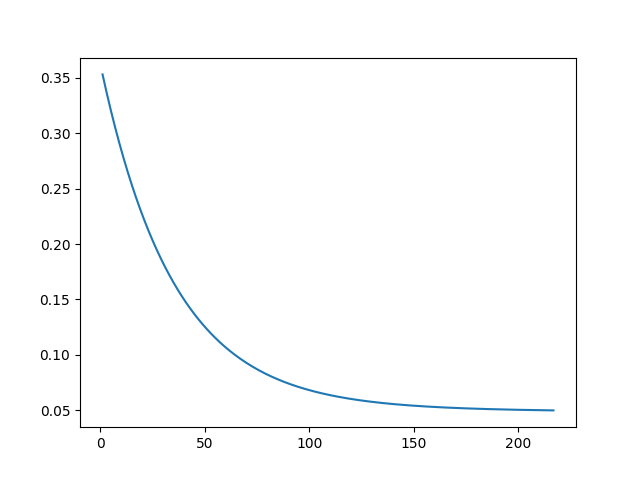

In [12]:
fig = plt.figure()
plt.plot(np.arange(1,len(arrL)+1), arrL)

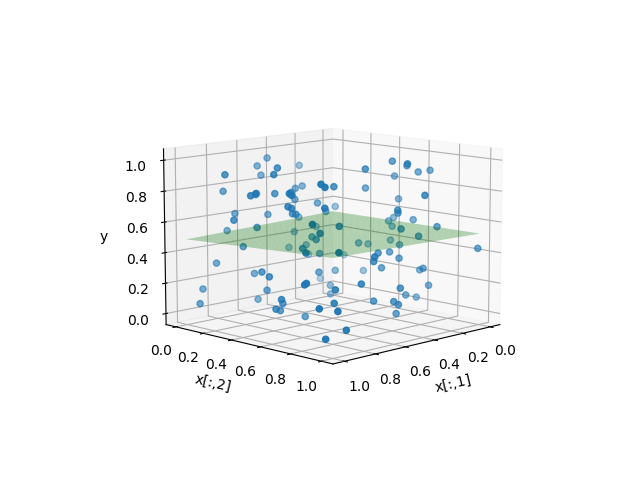

In [13]:
l_x = np.linspace(0,1,100)
l_y = np.linspace(0,1,100)

l_x, l_y = np.meshgrid(l_x, l_y)
l_z = paramArr[0] + paramArr[1]*l_x + paramArr[2]*l_y

# 3D PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x[:,1], x[:,2], y)
surf = ax.plot_surface(l_x, l_y, l_z, alpha=0.3, color="green")
ax.set_xlabel('x[:,1]')
ax.set_ylabel('x[:,2]')
ax.set_zlabel('y')
ax.view_init(10, 45)
